# Contexto del Negocio
Olist opera en Brasil como un integrador de e-commerce, conectando pequeñas empresas con los principales marketplaces del país. Para comprender la salud financiera y la tracción de la plataforma, es fundamental analizar la evolución de las ventas a lo largo del tiempo. El mercado brasileño de comercio electrónico es el más grande de América Latina, con una fuerte adopción tecnológica y eventos estacionales muy marcados.

### Pregunta de Negocio e Hipótesis
**Pregunta Principal:** ¿Cuál ha sido la tendencia de crecimiento de los ingresos de Olist desde su inicio y qué factores estacionales impactan en el volumen de ventas?

**Hipótesis:** Se espera observar una tendencia alcista producto de la adopción inicial de la plataforma, con picos pronunciados hacia finales de año impulsados por el Black Friday, un evento comercial que en Brasil ha ganado una tracción masiva en el canal online.

### Metodología y Extracción de Datos
Para responder a esta pregunta, se procedió de la siguiente manera:
1.  **Consulta SQL:** Se diseñó una consulta relacional para extraer la facturación mensual cruzando las tablas de órdenes (`orders`) y pagos (`order_payments`).
2.  **Limpieza de Datos:** Es crucial para un análisis financiero excluir aquellas órdenes que no se concretaron y, por ende, no generaron ingresos reales. Por ello, la consulta filtra los estados `canceled` (cancelados) y `unavailable` (no disponibles).
3.  **Procesamiento:** Se agregó el valor total de los pagos (`payment_value`) agrupado por mes y año (`mes_venta`).
4.  **Visualización:** Utilizando Python, se importaron los datos mediante `SQLAlchemy` y se generó un gráfico de líneas, el cual es ideal para observar la evolución temporal e identificar ciclos o tendencias a simple vista.


In [2]:
import os
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

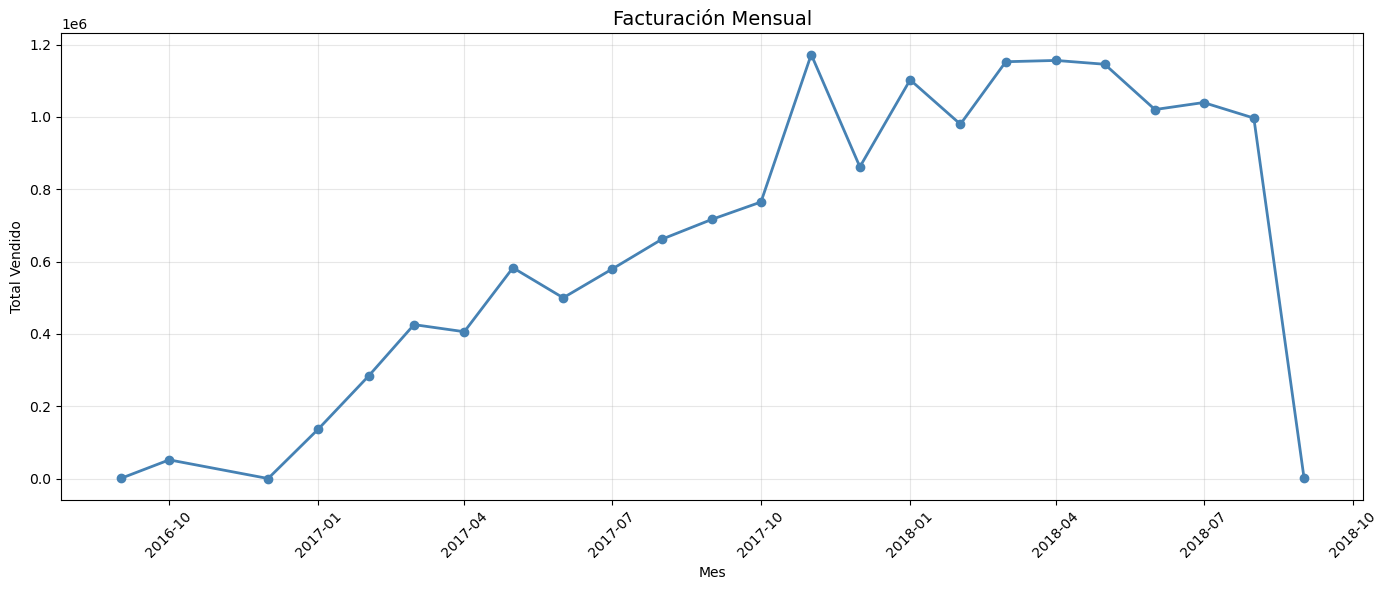

,mes_venta,total_vendido
0,2016-09-01,136.23
1,2016-10-01,51657.53
2,2016-12-01,19.62
3,2017-01-01,137006.76
4,2017-02-01,283621.94
5,2017-03-01,425656.40
6,2017-04-01,405988.38
7,2017-05-01,582926.16
8,2017-06-01,499827.47
9,2017-07-01,578858.58


In [3]:
# Conexión 
load_dotenv()
engine = create_engine(f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}")

# Función para leer archivo .sql y devolver un DataFrame
def ejecutar_query_desde_archivo(ruta_archivo):
    with open(ruta_archivo, 'r', encoding='utf-8') as archivo:
        query_sql = archivo.read()
    
    with engine.connect() as conexion:
        # read_sql ejecuta la consulta y arma el DataFrame
        df = pd.read_sql(text(query_sql), con=conexion)
    return df

df_facturacion = ejecutar_query_desde_archivo('queries/01_facturacion_mensual.sql')
# Convertir mes_venta a datetime para mejor visualización
df_facturacion['mes_venta'] = pd.to_datetime(df_facturacion['mes_venta'])

# Crear gráfico de línea para tendencia de facturación mensual
plt.figure(figsize=(14, 6))
plt.plot(df_facturacion['mes_venta'], df_facturacion['total_vendido'], marker='o', linewidth=2, color='steelblue')
plt.title('Facturación Mensual', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Total Vendido')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Ver el resultado exacto
df_facturacion

# Análisis de Facturación Mensual: Conclusiones y Hallazgos

A partir del análisis del gráfico de líneas y la tabla de datos de la facturación mensual, se extraen las siguientes conclusiones clave para el negocio de Olist:

### Fase de Crecimiento Acelerado
Los datos muestran un claro punto de inflexión a principios de 2017. Mientras que a finales de 2016 los volúmenes registrados eran marginales (debido a una fase inicial del negocio), a partir de enero de 2017 (R$ 137k) se observa un crecimiento sostenido e ininterrumpido hasta el último trimestre del año. Esto indica que Olist logró validar su modelo de negocio en el ecosistema brasileño, escalando rápidamente su base de clientes y transacciones.

### El Impacto de la Estacionalidad
El gráfico revela el pico máximo de facturación en **noviembre de 2017**, superando los **R$ 1.17 millones** en un solo mes (creciendo un 53% respecto al mes anterior). Este comportamiento refleja fuertemente la estacionalidad del mercado brasileño y está directamente correlacionado con el **Black Friday**. En Brasil, este evento es la fecha más importante del año para el comercio electrónico, generando una explosión de demanda que la plataforma de Olist logró absorber y capitalizar con éxito.

### Consolidación y Madurez en 2018
Tras el gran pico de noviembre, las ventas no retrocedieron a los niveles bajos de principios de 2017. En cambio, se estabilizaron en un nuevo estándar de facturación. Durante los primeros ocho meses de 2018, la plataforma mantuvo un volumen sólido y constante, fluctuando entre el millón y los R$ 1.15 millones mensuales. Esto demuestra no solo adquisición de nuevos clientes, sino retención y fidelización, operando ya en una fase de mayor madurez.

### Septiembre 2018
El mes de septiembre de 2018 está incompleto en la base de datos. Esta observación es crucial para evitar sesgos si se fuesen a realizar modelos de predicción a futuro con esta serie de tiempo.


# Análisis de Métodos de Pago y Cuotas: Metodología y Objetivos

### Contexto del Negocio
El ecosistema de pagos en Brasil tiene particularidades muy marcadas que definen el éxito de un e-commerce. Históricamente, el consumidor brasileño tiene una fuerte cultura de financiamiento de sus compras debido a la relación entre el costo de vida y los ingresos medios. Además, existe una gran porción de la población no bancarizada que tradicionalmente ha dependido de métodos de pago en efectivo, como el *Boleto Bancário*. Entender cómo pagan los usuarios de Olist es fundamental para optimizar la pasarela de pagos y maximizar la tasa de conversión.

### Pregunta de Negocio e Hipótesis
**Pregunta Principal:** ¿Cuáles son los métodos de pago preferidos por los clientes de Olist, cómo se distribuye el volumen de transacciones entre ellos, y cuál es el comportamiento de financiamiento (uso de cuotas) asociado a cada uno?

**Hipótesis:** Se espera que la tarjeta de crédito sea el método dominante debido a la facilidad para financiar compras en cuotas. Asimismo, se anticipa que el *boleto bancário* tenga una participación significativa y excluyente de cuotas (pago al contado), representando a un segmento demográfico específico o a clientes reacios a introducir datos bancarios online.

### Metodología y Extracción de Datos
Para llevar a cabo este análisis, el proceso consistió en:
1.  **Cálculo del Ticket Promedio:** Se ejecutó una consulta SQL para dividir el total de ingresos generados entre la cantidad de órdenes únicas, obteniendo un gasto promedio por compra de referencia general (**R$ 160.99**).
2.  **Agrupación por Método de Pago:** Se estructuró una consulta agrupando los registros de la tabla `order_payments` por el campo `payment_type`. Para cada método, se calculó el conteo total de transacciones y el promedio de cuotas.
3.  **Visualización Combinada:** Mediante la librería `matplotlib` y `seaborn` en Python, se diseñó un gráfico de doble eje. Un gráfico de barras (eje izquierdo) muestra el volumen de transacciones para identificar la popularidad del método, mientras que un gráfico de líneas superpuesto (eje derecho) revela la media de cuotas asociadas, permitiendo cruzar volumen y comportamiento financiero en una sola vista.

In [4]:
df_gasto = ejecutar_query_desde_archivo('queries/02_gasto_promedio.sql')

df_gasto

,gasto_promedio_por_compra
0,160.990267


/tmp/ipykernel_7066/3502148329.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='metodo_de_pago', y='cantidad_transacciones', data=df_plot, ax=ax_left, palette='viridis')
/tmp/ipykernel_7066/3502148329.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_left.set_xticklabels(ax_left.get_xticklabels(), rotation=45, ha='right')


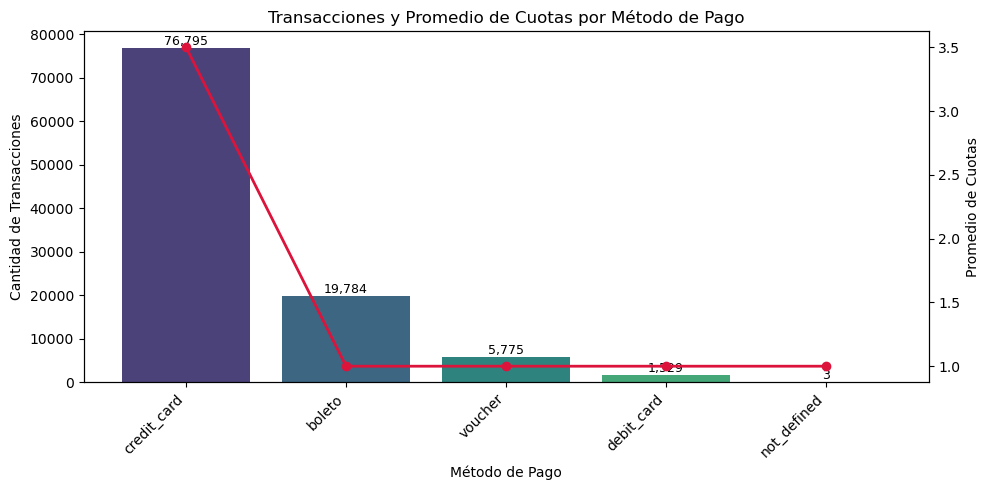

,metodo_de_pago,cantidad_transacciones,promedio_cuotas
0,credit_card,76795,3.5
1,boleto,19784,1.0
2,voucher,5775,1.0
3,debit_card,1529,1.0
4,not_defined,3,1.0


In [5]:
df_metodo_cuotas = ejecutar_query_desde_archivo('queries/03_metodo_cuotas.sql')

df_plot = df_metodo_cuotas.sort_values('cantidad_transacciones', ascending=False)

fig2, ax_left = plt.subplots(figsize=(10, 5))
sns.barplot(x='metodo_de_pago', y='cantidad_transacciones', data=df_plot, ax=ax_left, palette='viridis')
ax_left.set_xlabel('Método de Pago')
ax_left.set_ylabel('Cantidad de Transacciones')
ax_left.set_title('Transacciones y Promedio de Cuotas por Método de Pago')
ax_left.set_xticklabels(ax_left.get_xticklabels(), rotation=45, ha='right')

ax_right = ax_left.twinx()
ax_right.plot(df_plot['metodo_de_pago'], df_plot['promedio_cuotas'], color='crimson', marker='o', linewidth=2)
ax_right.set_ylabel('Promedio de Cuotas')

for p in ax_left.patches:
    ax_left.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2, p.get_height()), 
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
df_metodo_cuotas

# Análisis de Métodos de Pago y Cuotas: Conclusiones y Hallazgos

Al cruzar el ticket promedio de la plataforma con la distribución de métodos de pago y el volumen de cuotas, emergen conclusiones vitales para la estrategia comercial de Olist:

### El Dominio Absoluto de la Tarjeta de Crédito y el "Parcelamento"
La tarjeta de crédito es el método de pago más utilizado, acumulando **76,795 transacciones**. Lo más destacable es que es el único método que registra un promedio de cuotas superior a 1, situándose en **3.5 cuotas por compra**. 
*   **Implicancia de Negocio:** Sabiendo que el gasto promedio por compra es de **R$ 160.99**, financiar este monto en 3 o 4 cuotas hace que el producto sea accesible para la clase media brasileña. Ofrecer integraciones de pago con opciones en cuotas sin interés aparente (absorbiendo el costo financiero en el margen del producto) no es una ventaja competitiva, es un **requisito obligatorio** para operar en Brasil.

### La Relevancia del Boleto Bancário
El *Boleto* se posiciona como el segundo método más popular, con **19,784 transacciones**. Como es de esperar por su naturaleza (un comprobante impreso o digital que se paga en efectivo en bancos o loterías), su promedio de cuotas es estrictamente 1.0.
*   **Implicancia de Negocio:** Este método captura aproximadamente el 20% del volumen transaccional visible en los principales métodos. Representa a usuarios no bancarizados o a aquellos con desconfianza hacia el fraude online. Eliminar el Boleto de las opciones de *checkout* significaría perder automáticamente a una quinta parte de los compradores potenciales.

### Fricción Histórica en Tarjetas de Débito
La tarjeta de débito muestra una adopción marginal (**1,529 transacciones**). 
*   **Contexto del País:** En el período en el que se enmarca este dataset (2016-2018), el e-commerce brasileño sufría de una altísima fricción al usar tarjetas de débito online. Requerían autenticaciones complejas (como tokens físicos o redirecciones a los portales web de los bancos), lo que desplomaba las tasas de conversión. 

### Vouchers y Casos No Definidos
Los *vouchers* (vales, que suelen ser beneficios corporativos de alimentación/cultura o créditos de la tienda) representan un segmento de nicho pero saludable (**5,775 transacciones**), pagados siempre en una exhibición. Los casos `not_defined` son apenas 3 transacciones, lo que habla de una excelente calidad y limpieza en la ingesta de datos del sistema transaccional de Olist.

# Análisis Geográfico de Facturación: Metodología y Objetivos

### Contexto del Negocio
Brasil es un país de dimensiones continentales, caracterizado por una marcada desigualdad en la distribución demográfica, económica y de infraestructura. La región Sudeste concentra la mayor parte del PIB, la industria y el desarrollo tecnológico, mientras que las regiones Norte y Nordeste suelen enfrentar grandes desafíos logísticos. Para un integrador de e-commerce como Olist, entender la distribución geográfica de sus ingresos es fundamental para optimizar campañas de marketing, negociar tarifas de flete y planificar estrategias de expansión logística.

### Pregunta de Negocio e Hipótesis
**Pregunta Principal:** ¿Cómo se distribuye la facturación territorialmente a lo largo de los estados brasileños y cuáles son los mercados más valiosos para la plataforma?

**Hipótesis:** Se espera una fuerte concentración de los ingresos en la región Sudeste, liderada holgadamente por el estado de São Paulo (SP) debido a su gran densidad poblacional, su alto poder adquisitivo y la mejor infraestructura logística del país, la cual permite envíos más rápidos y económicos.

### Metodología y Extracción de Datos
Para responder a la pregunta de negocio, se estructuró el análisis de la siguiente forma:
1.  **Consulta SQL:** Se diseñó una consulta relacional uniendo tres tablas clave: `customers` (para obtener el estado de residencia del cliente, `customer_state`), `orders` (para trazar la relación transaccional) y `order_payments` (para obtener el valor monetario).
2.  **Agrupación:** Se sumó el valor total de los pagos agrupándolo por estado. Finalmente, se ordenaron los resultados de mayor a menor para facilitar la identificación de los líderes del mercado.
3.  **Visualización:** Utilizando la librería `seaborn` en Python, se generó un gráfico de barras. Este tipo de gráfico es óptimo para visualizar rankings categóricos y evidenciar la diferencia de magnitudes entre las distintas variables geográficas.

/tmp/ipykernel_7066/1066080246.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='estado', y='total_facturado', data=df_estados_mas_facturan, palette='coolwarm')


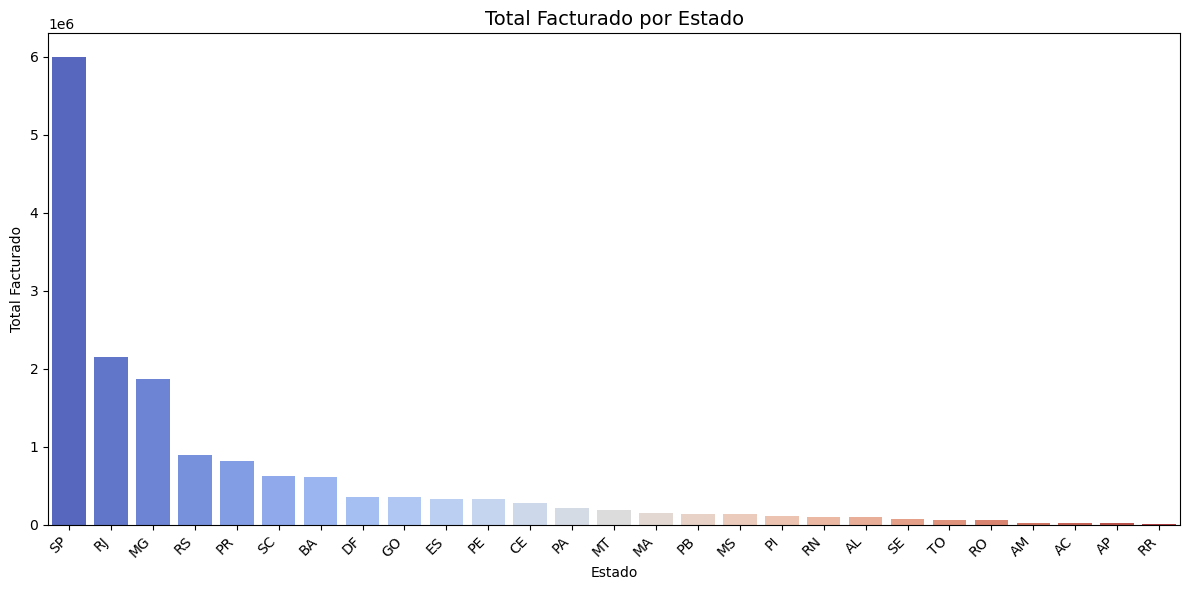

,estado,total_facturado
0,SP,5998226.96
1,RJ,2144379.69
2,MG,1872257.26
3,RS,890898.54
4,PR,811156.38
5,SC,623086.43
6,BA,616645.82
7,DF,355141.08
8,GO,350092.31
9,ES,325967.55


In [6]:
df_estados_mas_facturan = ejecutar_query_desde_archivo('queries/04_estados_mas_facturan.sql')
plt.figure(figsize=(12, 6))
sns.barplot(x='estado', y='total_facturado', data=df_estados_mas_facturan, palette='coolwarm')
plt.title('Total Facturado por Estado', fontsize=14)
plt.xlabel('Estado')
plt.ylabel('Total Facturado')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
df_estados_mas_facturan

# Análisis Geográfico de Facturación: Conclusiones y Hallazgos

El análisis del gráfico de barras y la tabla subyacente revela una pronunciada asimetría en la distribución de los ingresos por estado, ofreciendo las siguientes conclusiones estratégicas:

### El Dominio Absoluto de São Paulo (SP)
El estado de São Paulo es, indiscutiblemente, el motor de ventas de Olist. Con una facturación cercana a los **R$ 6 millones**, SP genera casi el triple de ingresos que el estado en la segunda posición. Este dominio se explica no solo por ser el centro financiero y poblacional de Brasil, sino también porque la gran mayoría de los vendedores (sellers) operan desde este estado. Esto genera envíos "intra-estado" que resultan mucho más baratos y rápidos, elevando significativamente la tasa de conversión.

### La Hegemonía del Polo Sudeste/Sur
Si agrupamos los primeros cinco estados del ranking —São Paulo (SP), Río de Janeiro (RJ con **R$ 2.14 millones**), Minas Gerais (MG con **R$ 1.87 millones**), Rio Grande do Sul (RS) y Paraná (PR)— observamos que concentran la inmensa mayoría de la facturación del país. Estas regiones (Sudeste y Sur) cuentan con el mejor ecosistema de conectividad e infraestructura terrestre, lo que valida la hipótesis de que el e-commerce en Brasil está profundamente atado a las facilidades logísticas regionales.

### El Desafío de la "Larga Cola" (Norte y Nordeste)
Al observar la caída exponencial en el gráfico de barras hacia la derecha, encontramos a los estados de las regiones Norte y Nordeste (como Roraima - RR, Amapá - AP, Acre - AC y Amazonas - AM). La facturación en estos estados es casi residual (rozando los **R$ 10,000** en el extremo más bajo). 
*   **Implicancia Logística:** Esta baja penetración suele estar correlacionada con plazos de entrega que pueden superar los 20 o 30 días y costos de flete que, en ocasiones, superan el valor del propio producto. Para Olist, penetrar en estos mercados requeriría estrategias disruptivas, como el establecimiento de centros de distribución regionales más cercanos a estas zonas para democratizar el acceso al e-commerce.

### Oportunidades en Estados Emergentes
Estados como Bahía (BA), Distrito Federal (DF) y Goiás (GO) lideran el "pelotón del medio", con ingresos entre los **R$ 350k y R$ 616k**. Estas áreas representan zonas de transición interesantes donde campañas de marketing dirigidas o subsidios parciales al flete podrían generar un salto rápido en el escalafón de facturación.

=== Top 10 categorías más vendidas ===
            categoria unidades_vendidas
       bed_bath_table            11,115
        health_beauty             9,670
       sports_leisure             8,641
      furniture_decor             8,334
computers_accessories             7,827
           housewares             6,964
        watches_gifts             5,991
            telephony             4,545
         garden_tools             4,347
                 auto             4,235

=== Top 10 categorías con mayor ingreso ===
            categoria total_ingresos_generados
        health_beauty             1,258,681.34
        watches_gifts             1,205,005.68
       bed_bath_table             1,036,988.68
       sports_leisure               988,048.97
computers_accessories               911,954.32
      furniture_decor               729,762.49
           cool_stuff               635,290.85
           housewares               632,248.66
                 auto               592,720.11
      

/tmp/ipykernel_7066/1996122354.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='categoria', y='unidades_vendidas', data=df_categorias_mas_vendidas, ax=ax1, palette='Blues_r')
/tmp/ipykernel_7066/1996122354.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_7066/1996122354.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='categoria', y='total_ingresos_generados', data=df_categorias_mas_ingresos, ax=ax2, palette='Greens_r')
/tmp/ipykernel_7066/1996122354.py:34: UserWarning: set_ticklabels() should only be used wi

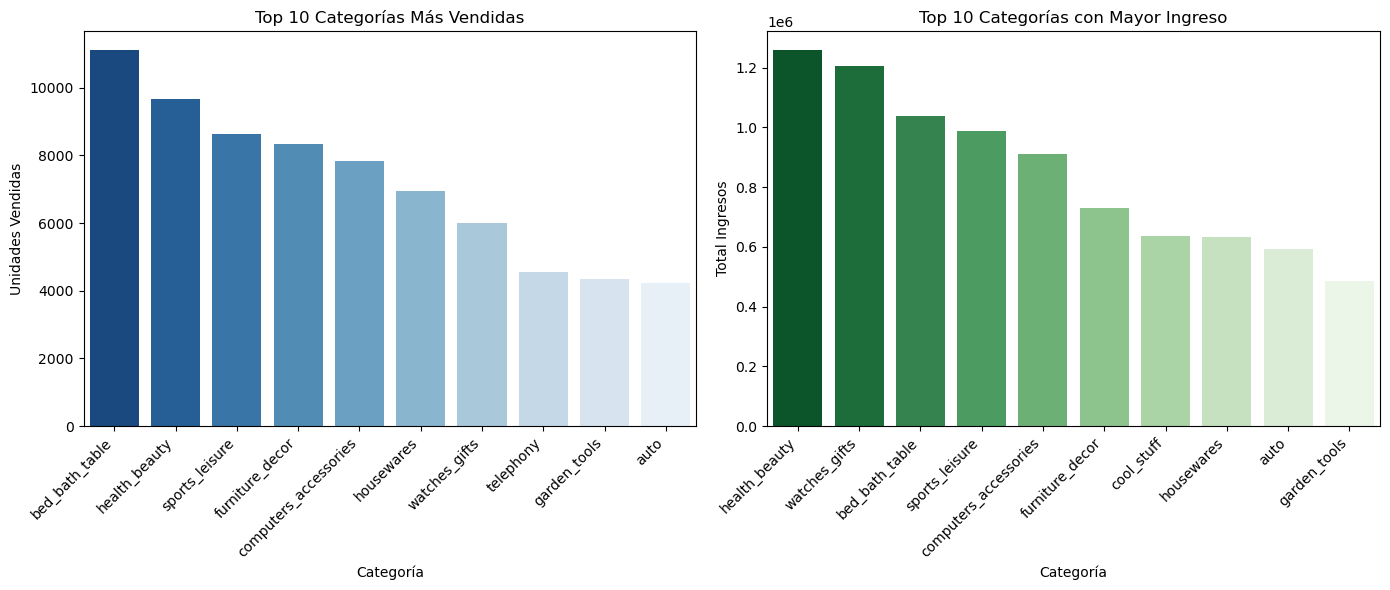

In [7]:
df_categorias_mas_ingresos = ejecutar_query_desde_archivo('queries/06_categorias_mas_ingresos.sql')
df_categorias_mas_vendidas = ejecutar_query_desde_archivo('queries/07_categorias_mas_vendidas.sql')

print("=== Top 10 categorías más vendidas ===")
print(
    df_categorias_mas_vendidas.to_string(
        index=False,
        formatters={"unidades_vendidas": "{:,.0f}".format}
    )
)

print("\n=== Top 10 categorías con mayor ingreso ===")
print(
    df_categorias_mas_ingresos.to_string(
        index=False,
        formatters={"total_ingresos_generados": "{:,.2f}".format}
    )
)
# Crear visualización comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de categorías más vendidas
sns.barplot(x='categoria', y='unidades_vendidas', data=df_categorias_mas_vendidas, ax=ax1, palette='Blues_r')
ax1.set_title('Top 10 Categorías Más Vendidas', fontsize=12)
ax1.set_xlabel('Categoría')
ax1.set_ylabel('Unidades Vendidas')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Gráfico de categorías con más ingresos
sns.barplot(x='categoria', y='total_ingresos_generados', data=df_categorias_mas_ingresos, ax=ax2, palette='Greens_r')
ax2.set_title('Top 10 Categorías con Mayor Ingreso', fontsize=12)
ax2.set_xlabel('Categoría')
ax2.set_ylabel('Total Ingresos')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()



In [8]:
df_logistica_tiempos_estados = ejecutar_query_desde_archivo('queries/08_logistica_tiempos_estados.sql')

df_logistica_tiempos_estados

,estado,promedio_dias_anticipacion,maximo_retraso_historico_dias
0,AL,8.7,50
1,MA,9.6,134
2,SE,10.0,166
3,ES,10.5,181
4,CE,10.8,132
5,BA,10.8,138
6,SP,11.1,175
7,MS,11.1,29
8,PI,11.3,161
9,SC,11.5,69


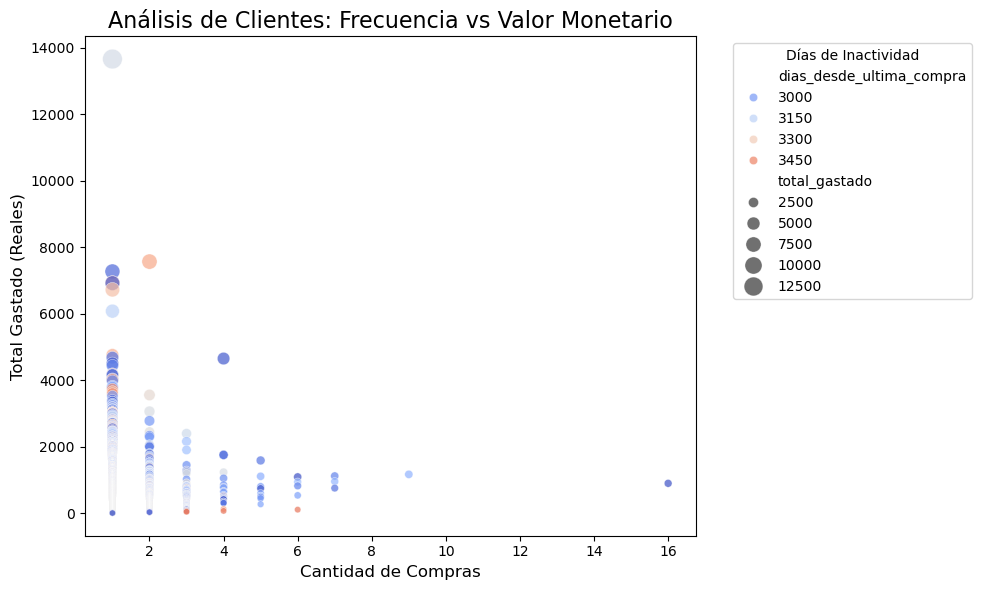

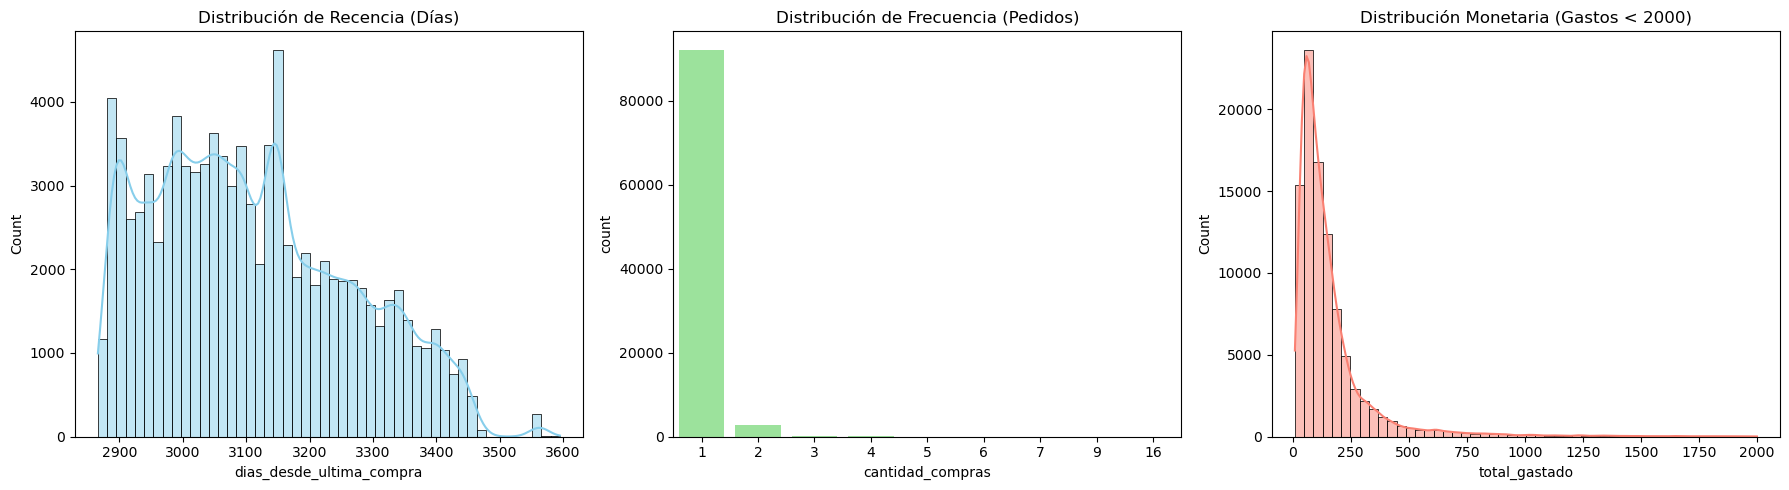

In [9]:
df_rfm = ejecutar_query_desde_archivo('queries/10_rfm.sql')

plt.figure(figsize=(10, 6))

scatter = sns.scatterplot(
    data=df_rfm, 
    x='cantidad_compras', 
    y='total_gastado', 
    hue='dias_desde_ultima_compra',
    palette='coolwarm',
    alpha=0.7,
    size='total_gastado',
    sizes=(20, 200)
)

plt.title('Análisis de Clientes: Frecuencia vs Valor Monetario', fontsize=16)
plt.xlabel('Cantidad de Compras', fontsize=12)
plt.ylabel('Total Gastado (Reales)', fontsize=12)
plt.legend(title='Días de Inactividad', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_rfm['dias_desde_ultima_compra'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Recencia (Días)')

sns.countplot(data=df_rfm, x='cantidad_compras', ax=axes[1], color='lightgreen')
axes[1].set_title('Distribución de Frecuencia (Pedidos)')

# Filtramos outliers extremos para que el gráfico sea legible
sns.histplot(df_rfm[df_rfm['total_gastado'] < 2000]['total_gastado'], bins=50, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Distribución Monetaria (Gastos < 2000)')

plt.tight_layout()
plt.show()


=== Resumen ===
Registros analizados: 96,353

Cantidad por estado del envío:
estado_envio
A Tiempo     89944
Retrasado     6409

Promedio de review_score por estado del envío:
estado_envio
A Tiempo     4.290
Retrasado    2.271

Promedio de días de anticipación por estado del envío:
estado_envio
A Tiempo     13.516
Retrasado   -10.527

Correlación entre días de anticipación y review_score:
0.2670


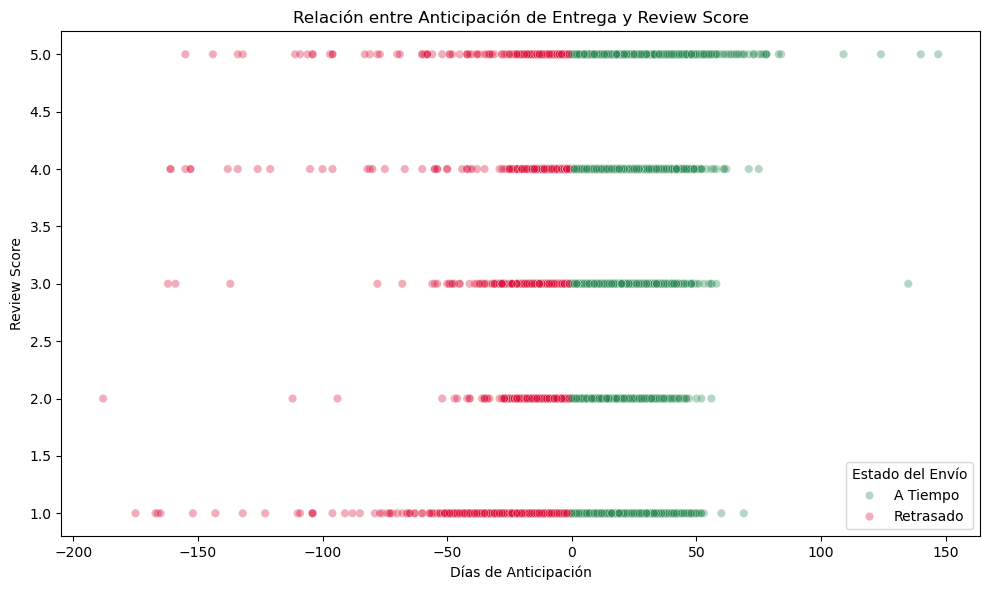

In [10]:
df_logistica_tiempos_indiv = ejecutar_query_desde_archivo('queries/09_logistica_tiempos_indiv.sql')
df_plot_logistica = df_logistica_tiempos_indiv.copy()

plt.figure(figsize=(10, 6))
df_plot_logistica['estado_envio'] = df_plot_logistica['dias_anticipacion'].apply(
    lambda x: 'Retrasado' if x < 0 else 'A Tiempo'
)

print("=== Resumen ===")
print(f"Registros analizados: {len(df_plot_logistica):,}")
print("\nCantidad por estado del envío:")
print(df_plot_logistica['estado_envio'].value_counts().to_string())

print("\nPromedio de review_score por estado del envío:")
print(
    df_plot_logistica.groupby('estado_envio')['review_score']
    .mean()
    .round(3)
    .to_string()
)

print("\nPromedio de días de anticipación por estado del envío:")
print(
    df_plot_logistica.groupby('estado_envio')['dias_anticipacion']
    .mean()
    .round(3)
    .to_string()
)

print("\nCorrelación entre días de anticipación y review_score:")
print(f"{df_plot_logistica[['dias_anticipacion', 'review_score']].corr().iloc[0, 1]:.4f}")

sns.scatterplot(
    data=df_plot_logistica,
    x='dias_anticipacion',
    y='review_score',
    hue='estado_envio',
    alpha=0.35,
    palette={'A Tiempo': 'seagreen', 'Retrasado': 'crimson'}
)

plt.title('Relación entre Anticipación de Entrega y Review Score')
plt.xlabel('Días de Anticipación')
plt.ylabel('Review Score')
plt.legend(title='Estado del Envío')
plt.tight_layout()
plt.show()

--- Impacto en el Review Score Promedio ---
estado_envio
A Tiempo     4.289980
Retrasado    2.271025
Name: review_score, dtype: float64

--- Distribución Porcentual de las Calificaciones ---
review_score          1        2          3          4          5
estado_envio                                                     
A Tiempo       6.627457  2.65165   8.076136  20.384906  62.259851
Retrasado     53.736932  8.67530  10.875332  10.173194  16.539242


/tmp/ipykernel_7066/2555206898.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='estado_envio', y='review_score', data=df_logistica_tiempos_indiv, palette='magma', errorbar=None)


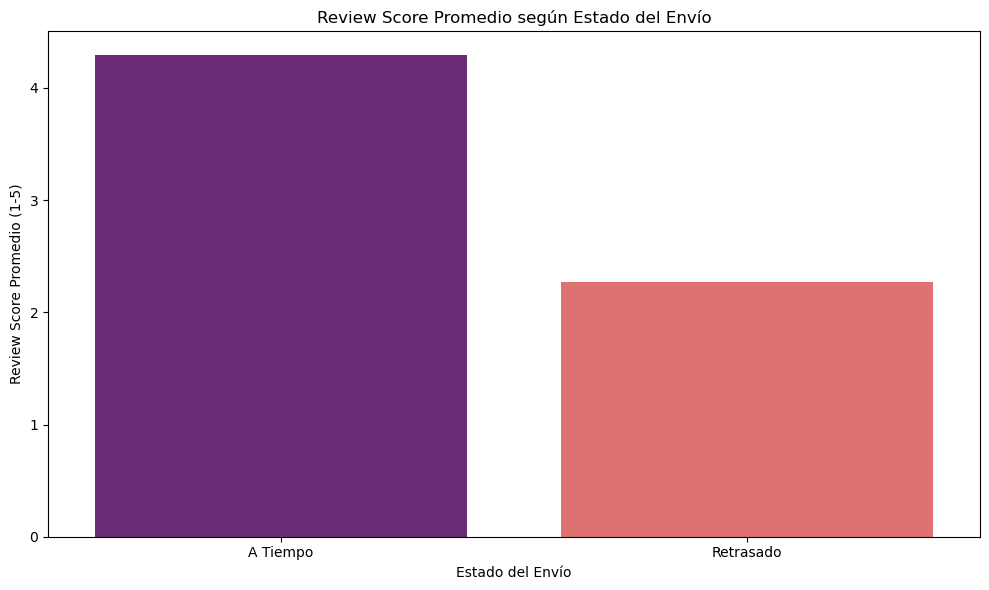

In [11]:
# Si los días de anticipación son menores a 0, el pedido se retrasó.
df_logistica_tiempos_indiv['estado_envio'] = df_logistica_tiempos_indiv['dias_anticipacion'].apply(
    lambda x: 'Retrasado' if x < 0 else 'A Tiempo'
)

print("--- Impacto en el Review Score Promedio ---")
print(df_logistica_tiempos_indiv.groupby('estado_envio')['review_score'].mean())

print("\n--- Distribución Porcentual de las Calificaciones ---")
print(pd.crosstab(df_logistica_tiempos_indiv['estado_envio'], df_logistica_tiempos_indiv['review_score'], normalize='index') * 100)

plt.figure(figsize=(10, 6))

# Gráfico de barras para comparar el Review Score promedio
sns.barplot(x='estado_envio', y='review_score', data=df_logistica_tiempos_indiv, palette='magma', errorbar=None)
plt.title('Review Score Promedio según Estado del Envío')
plt.xlabel('Estado del Envío')
plt.ylabel('Review Score Promedio (1-5)')

plt.tight_layout()
plt.show()

--- Matriz de Correlación de Pearson ---
                        precio  costo_del_transporte  peso_producto_gramos  \
precio                1.000000              0.414333              0.338819   
costo_del_transporte  0.414333              1.000000              0.610420   
peso_producto_gramos  0.338819              0.610420              1.000000   
volumen_producto_cm3  0.298754              0.587270              0.802267   

                      volumen_producto_cm3  
precio                            0.298754  
costo_del_transporte              0.587270  
peso_producto_gramos              0.802267  
volumen_producto_cm3              1.000000  


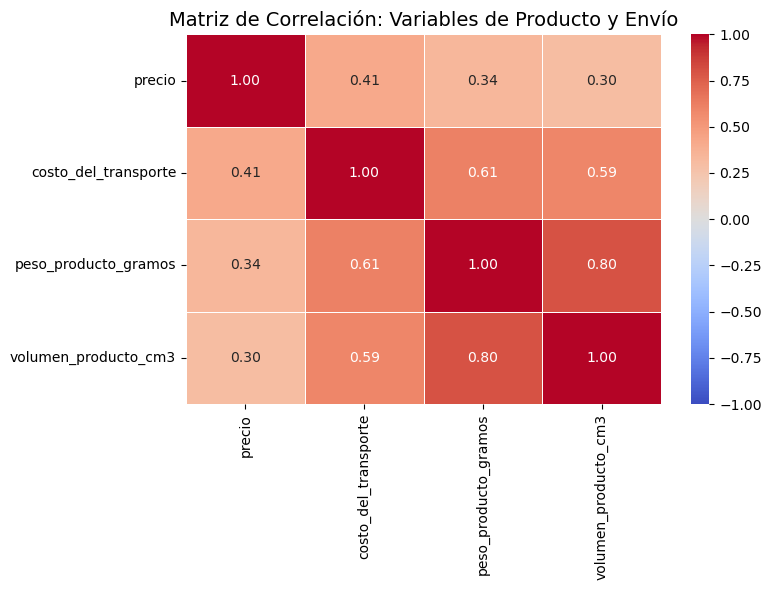

In [12]:
df_precio_envio_correlacion = ejecutar_query_desde_archivo('queries/11_precio_envio_correlacion.sql')

columnas_analisis = ['precio', 'costo_del_transporte', 'peso_producto_gramos', 'volumen_producto_cm3']
df_num = df_precio_envio_correlacion[columnas_analisis].dropna()

# Matriz de correlación
matriz_corr = df_num.corr(method='pearson')

print("--- Matriz de Correlación de Pearson ---")
print(matriz_corr)

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_corr, 
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title('Matriz de Correlación: Variables de Producto y Envío', fontsize=14)
plt.tight_layout()
plt.show()

--- Diagnóstico de Pareto ---
El 80% de la facturación es generado por las primeras 16 categorías.
Esto equivale aproximadamente al 21.92% del catálogo total.


/tmp/ipykernel_7066/745387562.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_category_name', y='ingresos_categoria', data=df_top, ax=ax1, palette='Blues_r')
/tmp/ipykernel_7066/745387562.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


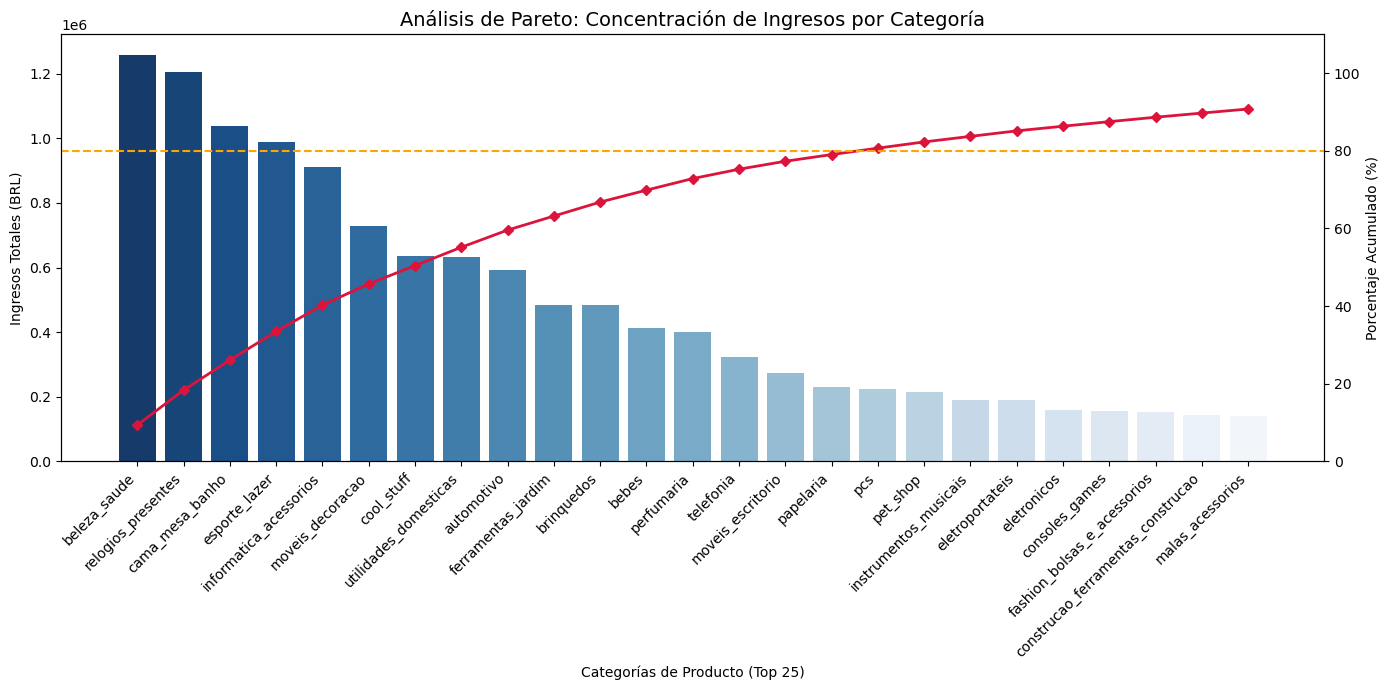

In [13]:
df_pareto = ejecutar_query_desde_archivo('queries/12_pareto.sql')
# Columna para saber qué porcentaje de las categorías representa cada fila
df_pareto['porcentaje_categorias'] = (pd.Series(range(1, len(df_pareto) + 1), index=df_pareto.index) / len(df_pareto)) * 100

# Punto donde se cruza el 80% de la facturación
punto_critico = df_pareto[df_pareto['porcentaje_acumulado'] <= 80].iloc[-1]

print(f"--- Diagnóstico de Pareto ---")
print(f"El 80% de la facturación es generado por las primeras {df_pareto[df_pareto['porcentaje_acumulado'] <= 80].shape[0]} categorías.")
print(f"Esto equivale aproximadamente al {punto_critico['porcentaje_categorias']:.2f}% del catálogo total.")

fig, ax1 = plt.subplots(figsize=(14, 7))

# Filtramos el top 25
df_top = df_pareto.head(25)

# Barras para los ingresos puros por categoría
sns.barplot(x='product_category_name', y='ingresos_categoria', data=df_top, ax=ax1, palette='Blues_r')
ax1.set_title('Análisis de Pareto: Concentración de Ingresos por Categoría', fontsize=14)
ax1.set_xlabel('Categorías de Producto (Top 25)')
ax1.set_ylabel('Ingresos Totales (BRL)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(df_top['product_category_name'], df_top['porcentaje_acumulado'], color='crimson', marker='D', ms=5, linewidth=2)
ax2.set_ylabel('Porcentaje Acumulado (%)')
ax2.set_ylim(0, 110)

# La línea punteada del umbral del 80%
ax2.axhline(80, color='orange', linestyle='--', label='Umbral 80% Facturación')

plt.tight_layout()
plt.show()